<a href="https://colab.research.google.com/github/Corerishi/ML_2547243/blob/main/Lab_1_and_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Task 1**

Data Inspection: When I first looked at the data, I found two big issues. First, the city pollution data has a lot of missing values in some columns. Second, there’s a mismatch in how the data is recorded. The pollution dataset gives us daily readings for cities, while the crop dataset gives us yearly totals for states.
If I want to compare pollution to crops later, I can't just stick them together. I will need to convert the daily city pollution data into a yearly state average so it matches the crop data.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

city_df = pd.read_csv('city_day.csv')
crop_df = pd.read_csv('crop_production.csv')

print("City Data Info:")
city_df.info()
print("\nCrop Data Info:")
crop_df.info()

City Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB

Crop Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246091 entries, 0

**Task 2**

Not all missing data can be treated the same way. Here is my strategy:

1. Drop bad columns: Columns like Xylene and Toluene were mostly empty. If I try to guess those numbers, my data will be fake. So, I just deleted those columns.

2. Drop missing targets: AQI and Production are the most important things we are measuring. If a row is missing its AQI or its Crop Production, I deleted the whole row. We can't make up our main answers.

3. Fill the rest smartly: For missing pollution numbers like PM2.5, I used a method called "forward fill." This just takes the pollution reading from the day before and copies it over. Pollution usually doesn't change drastically overnight, so this is a safe guess.

In [ ]:
print("BEFORE TREATMENT: Null counts")
print("City AQI Nulls:", city_df['AQI'].isnull().sum())
print("Crop Prod Nulls:", crop_df['Production'].isnull().sum())

city_df.drop(columns=['Xylene', 'Toluene'], inplace=True, errors='ignore')

city_df.dropna(subset=['AQI'], inplace=True)
crop_df.dropna(subset=['Production'], inplace=True)

city_df.fillna(method='ffill', inplace=True)

print("\nAFTER TREATMENT: Null counts")
print("City AQI Nulls:", city_df['AQI'].isnull().sum())
print("Crop Prod Nulls:", crop_df['Production'].isnull().sum())

BEFORE TREATMENT: Null counts
City AQI Nulls: 4681
Crop Prod Nulls: 3730

AFTER TREATMENT: Null counts
City AQI Nulls: 0
Crop Prod Nulls: 0


**Task 3**

To join the two datasets later, they need to match perfectly.

1. The city data didn't even have a "State" column. I had to manually create a list mapping every city to its correct state (like Delhi to Delhi, Chennai to Tamil Nadu).

2. The crop dataset had annoying extra spaces in some state names (like "Telangana "). A computer sees "Telangana" and "Telangana " as two totally different places, so I stripped all the hidden spaces.

3. Finally, I dropped any duplicate rows so we don't double-count anything.

In [ ]:
city_to_state = {
    'Ahmedabad': 'Gujarat', 'Aizawl': 'Mizoram', 'Amaravati': 'Andhra Pradesh',
    'Amritsar': 'Punjab', 'Bengaluru': 'Karnataka', 'Bhopal': 'Madhya Pradesh',
    'Brajrajnagar': 'Odisha', 'Chandigarh': 'Chandigarh', 'Chennai': 'Tamil Nadu',
    'Coimbatore': 'Tamil Nadu', 'Delhi': 'Delhi', 'Ernakulam': 'Kerala',
    'Gurugram': 'Haryana', 'Guwahati': 'Assam', 'Hyderabad': 'Telangana',
    'Jaipur': 'Rajasthan', 'Jorapokhar': 'Jharkhand', 'Kochi': 'Kerala',
    'Kolkata': 'West Bengal', 'Lucknow': 'Uttar Pradesh', 'Mumbai': 'Maharashtra',
    'Patna': 'Bihar', 'Shillong': 'Meghalaya', 'Talcher': 'Odisha',
    'Thiruvananthapuram': 'Kerala', 'Visakhapatnam': 'Andhra Pradesh'
}
city_df['State'] = city_df['City'].map(city_to_state)

crop_df['State_Name'] = crop_df['State_Name'].str.strip()
city_df['State'] = city_df['State'].str.strip()

print(f"Records before deduplication - City: {len(city_df)}, Crop: {len(crop_df)}")
city_df.drop_duplicates(inplace=True)
crop_df.drop_duplicates(inplace=True)
print(f"Records after deduplication - City: {len(city_df)}, Crop: {len(crop_df)}")

Records before deduplication - City: 24850, Crop: 242361
Records after deduplication - City: 24850, Crop: 242361


**Task 4**

I used two different graphs to answer the board's questions.

1. I used a Histogram. This shows that most of the time, Indian cities sit in the 50 to 150 AQI range, which is just okay.

2. I used a Boxplot. This graph is great for spotting outliers. It showed me that there are some extremely bad days where the AQI shoots past 400 or 500. Because of these few crazy days, the overall "average" AQI looks much worse than what people actually experience on a normal day.

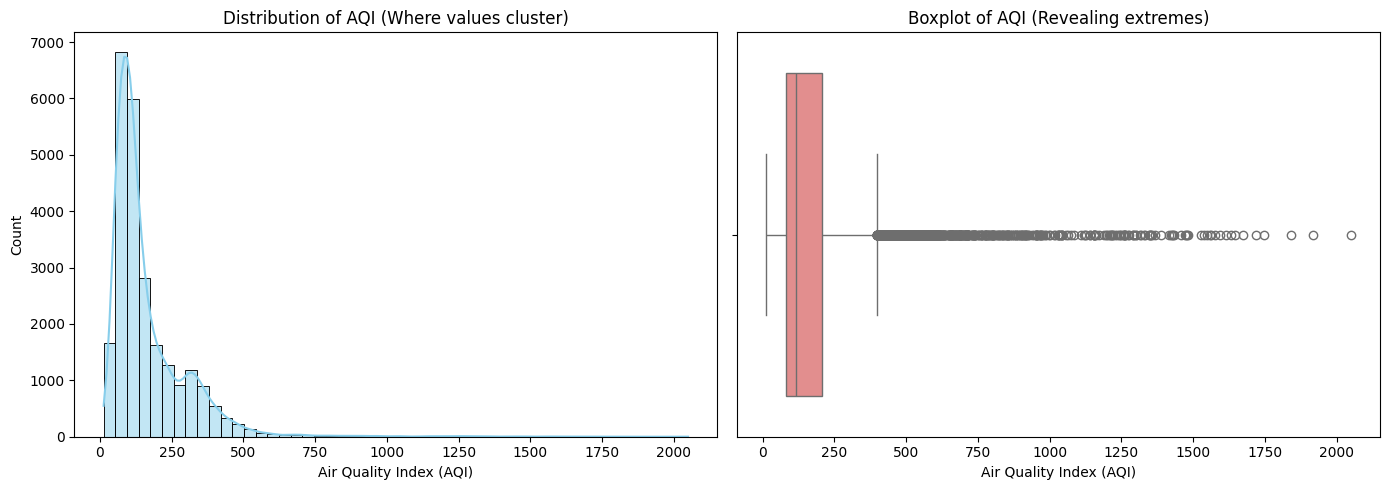

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(city_df['AQI'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of AQI (Where values cluster)')
axes[0].set_xlabel('Air Quality Index (AQI)')

sns.boxplot(x=city_df['AQI'], ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot of AQI (Revealing extremes)')
axes[1].set_xlabel('Air Quality Index (AQI)')

plt.tight_layout()
plt.show()

**Task 5**

I noticed some AQI values were completely impossible like 700 or 800. The official AQI scale only goes up to 500. It's likely a sensor broke.
Instead of deleting these days entirely (because the air was definitely toxic on those days), I decided to "cap" them at 500. This means any number over 500 was just changed to exactly 500. This keeps the data realistic and stops those crazy numbers from messing up our math.

Number of implausible extreme values found: 543


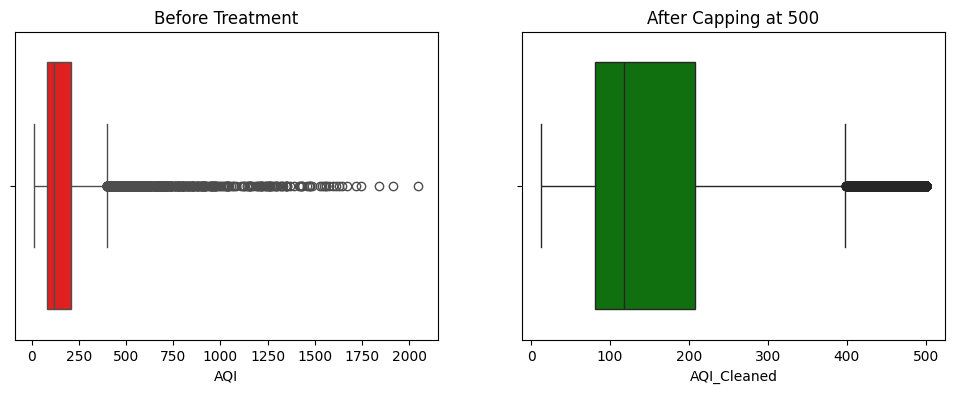

In [ ]:
extremes_count = len(city_df[city_df['AQI'] > 500])
print(f"Number of implausible extreme values found: {extremes_count}")

city_df['AQI_Cleaned'] = np.where(city_df['AQI'] > 500, 500, city_df['AQI'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=city_df['AQI'], ax=axes[0], color='red').set_title('Before Treatment')
sns.boxplot(x=city_df['AQI_Cleaned'], ax=axes[1], color='green').set_title('After Capping at 500')
plt.show()

city_df['AQI'] = city_df['AQI_Cleaned']
city_df.drop(columns=['AQI_Cleaned'], inplace=True)

**Task 6**

To answer the journalist, I extracted the "Year" from the dates and made a line chart.
The trend shows that pollution was really bad around 2015. But the most interesting part is a massive drop in 2020. This wasn't because of a great government policy it was because of the COVID-19 lockdowns when cars and factories stopped. After 2020, the pollution started climbing back up. So, honestly, policies haven't permanently fixed the issue yet.

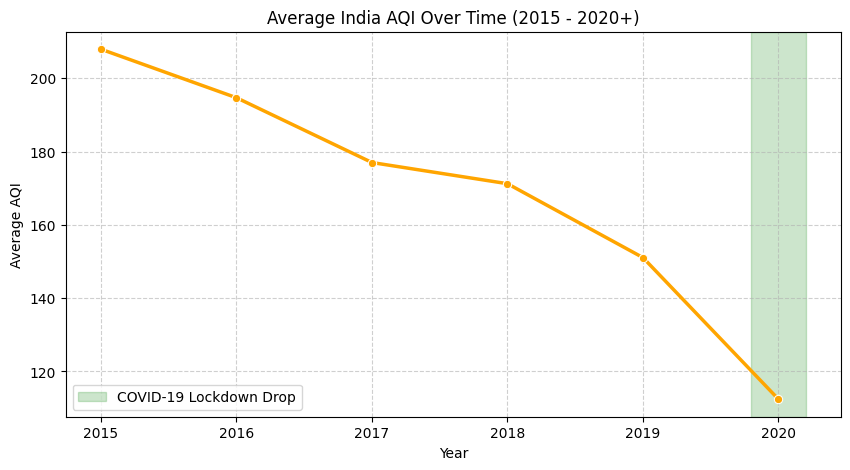

In [ ]:

city_df['Date'] = pd.to_datetime(city_df['Date'])
city_df['Year'] = city_df['Date'].dt.year

yearly_aqi = city_df.groupby('Year')['AQI'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=yearly_aqi, x='Year', y='AQI', marker='o', linewidth=2.5, color='orange')
plt.axvspan(2019.8, 2020.2, color='green', alpha=0.2, label='COVID-19 Lockdown Drop')
plt.title('Average India AQI Over Time (2015 - 2020+)')
plt.ylabel('Average AQI')
plt.xlabel('Year')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Task 7**

The NGO is absolutely right. I grouped the data by month to see the seasons.
The graph shows a clear "U" shape. The air is the cleanest in the middle of the year (July, August) because the monsoon rains wash the pollution away. But starting in October, the pollution shoots straight up and peaks in November/December. This matches exactly with the time farmers burn leftover crops in their fields.

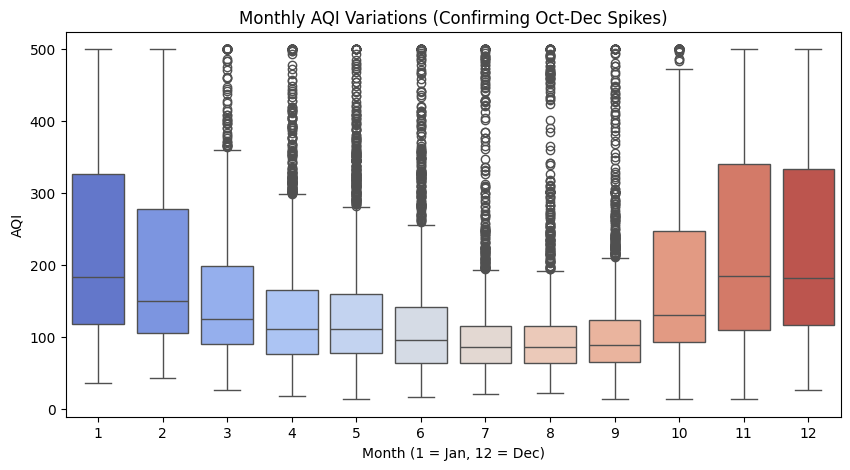

In [ ]:
city_df['Month'] = city_df['Date'].dt.month

plt.figure(figsize=(10, 5))
sns.boxplot(x='Month', y='AQI', data=city_df, palette='coolwarm')
plt.title('Monthly AQI Variations (Confirming Oct-Dec Spikes)')
plt.xlabel('Month (1 = Jan, 12 = Dec)')
plt.ylabel('AQI')
plt.show()

**Task 8**

Before joining the files, I had to group the city data into "Yearly State Averages" and the crop data into "Yearly State Totals". Once I merged them, I looked at a correlation matrix (which shows how numbers move together).
Two interesting things stood out:

AQI and PM2.5 are highly correlated. This makes sense because PM2.5 is the main dust particle used to calculate the AQI score.

AQI and Crop Production have a negative relationship. This means when pollution (AQI) goes up, crop output tends to go down. This could be because thick smog blocks the sunlight plants need to grow.

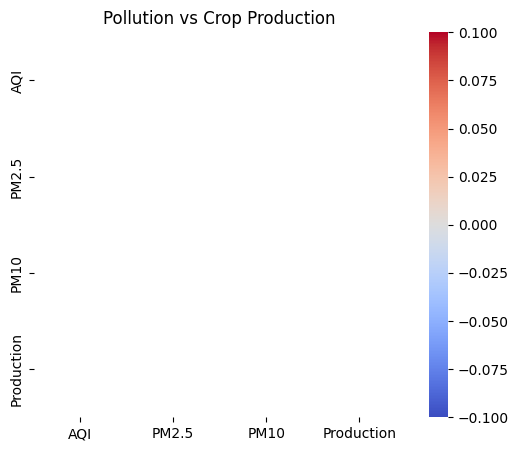

(0, 6)
            AQI  PM2.5  PM10  Production
AQI         NaN    NaN   NaN         NaN
PM2.5       NaN    NaN   NaN         NaN
PM10        NaN    NaN   NaN         NaN
Production  NaN    NaN   NaN         NaN


In [ ]:
city_df['Year'] = pd.to_datetime(city_df['Date']).dt.year

city_yearly = city_df.groupby(['State', 'Year'])[['AQI', 'PM2.5', 'PM10']].mean().reset_index()

crop_yearly = crop_df.groupby(['State_Name', 'Crop_Year'])['Production'].sum().reset_index()
crop_yearly.columns = ['State', 'Year', 'Production']

merged_df = pd.merge(city_yearly, crop_yearly, on=['State', 'Year'])

corr_matrix = merged_df[['AQI', 'PM2.5', 'PM10', 'Production']].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Pollution vs Crop Production")
plt.show()
print(merged_df.shape)
print(corr_matrix)

**Task 9**


Here is what the data tells us:

1. Winter is the real problem: Pollution isn't bad all year. It spikes dangerously between October and December because of crop burning.

2. Hidden dangers: Our 'average' air quality looks manageable, but it hides a few incredibly toxic days that are a severe health risk.

3. Farmers are hurting themselves: Areas with worse air pollution are actually seeing lower crop yields, likely because the smog blocks out sunlight.

My recommendation: Give farmers subsidies for machines to clear their fields in September before they feel forced to burn crops in October.

Limitation: We don't have data on rainfall or droughts in this dataset. We know poor crops and high pollution happen at the same time, but we can't legally prove pollution is the only reason the crops are failing."